In [1]:
import numpy as np
import matplotlib.pyplot as plt
def sigmoid(s):
    return 1 / (1 + np.exp(-s))

In [2]:
def prob(w, X):
    # X is a 2D ndarray of shape (N, d) where N is the number of data points,
    # and d is the dimension of each data point
    # w is a 1D ndarray of shape (d,)
    
    return sigmoid(X.dot(w))

def loss(w, X, y, lam):
    # X, w as in prob
    # y is a 1D ndarray of shape(N,). Each element is equal to 0 or 1
    # lam is the regularization parameter 
    a = prob(w, X)
    loss_0 = -np.mean(y * np.log(a) + (1 - y) * np.log(1 - a))
    weight_decay = 1 / len(a) * 0.5 * lam * np.linalg.norm(w) ** 2
    return loss_0 + weight_decay

In [3]:
def logistic_regression(w_init, X, y, lam, lr=0.1, nepoches=5000):
    N, d = X.shape[0], X.shape[1]
    w = w_old = w_init
    
    loss_hist = [loss(w_init, X, y, lam)]
    ep = 0
    while ep < nepoches:
        ep += 1
        mix_ids = np.random.permutation(N)
        for i in mix_ids:
            xi = X[i]
            yi = y[i]
            ai = sigmoid(xi.dot(w))
            w = w - lr * ((ai - yi) * xi + lam * w)
            loss_hist.append(loss(w, X, y, lam))
        if np.linalg.norm(w - w_old) < 1e-6:
            break
        w_old = w
    return w, loss_hist

In [27]:
np.random.seed(2)
X = np.array([[0.50, 0.75, 1.00, 1.25, 1.50, 1.75, 1.75, 2.00, 2.25, 2.50,
2.75, 3.00, 3.25, 3.50, 4.00, 4.25, 4.50, 4.75, 5.00, 5.50]]).T
y = np.array([0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1])
# bias trick
Xbar = np.concat((np.ones((X.shape[0], 1)), X), axis=1)
w_init = np.random.randn(Xbar.shape[1])
lam = 0.01
w, loss_hist = logistic_regression(w_init, Xbar, y, lam)
print('Solution of Logistic Regression: [w, b] = ', w)
print('Final loss:', loss(w, Xbar, y, lam))

Solution of Logistic Regression: [w, b] =  [-2.75518112  1.16420759]
Final loss: 0.4262757427811184


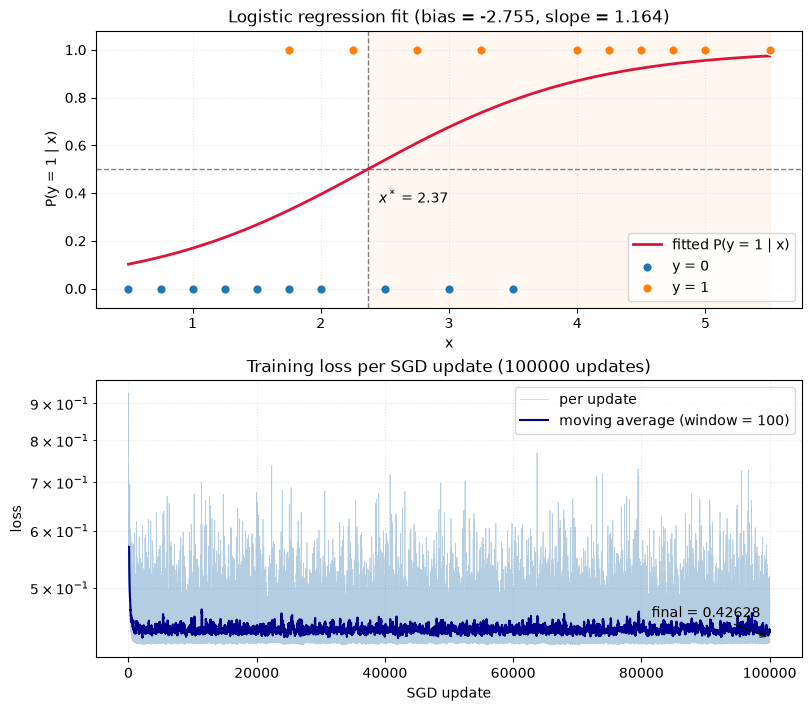

In [20]:
fig, ax = plt.subplots(2, 1, figsize=(8, 7), layout='constrained')

# ---------- Panel 1: data + fitted probability curve ----------
Xplot = np.linspace(X.min(), X.max(), 500)
x_data = X.ravel()   # X has shape (N, 1) -> flatten to (N,)

# model: z = w[0] + w[1] * x  (bias is the first column of Xbar),
# so P(y = 1 | x) = sigmoid(w[0] + w[1] * x)
ax[0].plot(Xplot, sigmoid(w[0] + w[1] * Xplot), color='crimson', lw=2,
           label='fitted P(y = 1 | x)', zorder=3)

ax[0].scatter(x_data[y == 0], y[y == 0], s=45, color='tab:blue',
              edgecolor='white', linewidth=0.8, label='y = 0', zorder=4)
ax[0].scatter(x_data[y == 1], y[y == 1], s=45, color='tab:orange',
              edgecolor='white', linewidth=0.8, label='y = 1', zorder=4)

# decision boundary: sigmoid(w[0] + w[1] * x) = 0.5  <=>  x* = -w[0] / w[1]
x_star = -w[0] / w[1]
ax[0].axhline(0.5, color='gray', linestyle='--', linewidth=1)
ax[0].axvline(x_star, color='gray', linestyle='--', linewidth=1)
ax[0].axvspan(x_star, Xplot.max(), color='tab:orange', alpha=0.06, zorder=0)
ax[0].annotate(f'$x^*$ = {x_star:.2f}', xy=(x_star, 0.5),
               xytext=(8, -24), textcoords='offset points', fontsize=10)

ax[0].set(xlim=(Xplot[0] - 0.25, Xplot[-1] + 0.25), ylim=(-0.08, 1.08),
          xlabel='x', ylabel='P(y = 1 | x)',
          title=f'Logistic regression fit (bias = {w[0]:.3f}, slope = {w[1]:.3f})')
ax[0].grid(alpha=0.3, linestyle=':')
ax[0].legend(loc='lower right')

# ---------- Panel 2: loss curve ----------
ax[1].plot(np.arange(len(loss_hist)), loss_hist, color='steelblue',
           linewidth=0.5, alpha=0.4, label='per update')
window = 100
if len(loss_hist) >= window:
    ma = np.convolve(loss_hist, np.ones(window) / window, mode='valid')
    ax[1].plot(np.arange(window - 1, len(loss_hist)), ma,
               color='darkblue', linewidth=1.5,
               label=f'moving average (window = {window})')

ax[1].set(yscale='log', xlabel='SGD update', ylabel='loss',
          title=f'Training loss per SGD update ({len(loss_hist) - 1} updates)')
ax[1].grid(alpha=0.3, linestyle=':', which='both')
ax[1].legend(loc='upper right')
ax[1].annotate(f'final = {loss_hist[-1]:.5f}',
               xy=(len(loss_hist) - 1, loss_hist[-1]),
               xytext=(-85, 15), textcoords='offset points',
               arrowprops=dict(arrowstyle='->', linewidth=0.8));

In [6]:
# Check answer with scikit-learn library
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression().fit(X, y)
w_sklearn = np.array([clf.intercept_[0], clf.coef_[0][0]])
loss(w_sklearn, Xbar, y, lam)

np.float64(0.41370520669818334)